<a href="https://colab.research.google.com/github/anilegin/latent-diffusion/blob/main/lightweight_ldm_anilegin_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lightweight Diffusion LDM — Colab Inference Notebook

This notebook is a **Colab** version for `anilegin/lightweight-diffusion-ldm`.

- Use `fp16` by default for better Colab GPU compatibility.
- Use `--low-vram` and `--decode-batch-size 1` by default.


## 1. Check GPU

Run this first. If CUDA is not available, go to **Runtime → Change runtime type → GPU**.


In [1]:
import torch

print("PyTorch:", torch.__version__)
print("PyTorch CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError("CUDA is not available. In Colab, enable Runtime > Change runtime type > GPU.")

PyTorch: 2.11.0+cu128
PyTorch CUDA build: 12.8
CUDA available: True
GPU: Tesla T4


## 2. Install Colab dependencies



In [2]:
!pip uninstall -y torchaudio

!pip install -q -U \
  "huggingface_hub[hf_xet]>=0.23" \
  "transformers==4.44.2" \
  PyYAML \
  Pillow \
  tqdm \
  python-dotenv

## 3. Download the Hugging Face repo

The repo contains custom source code and checkpoint files. This is not a native `diffusers` pipeline, so the full repo is required.


In [3]:
from huggingface_hub import snapshot_download
from pathlib import Path

REPO_ID = "anilegin/lightweight-diffusion-ldm"
LOCAL_DIR = Path("/content/lightweight-diffusion-ldm")

snapshot_download(
    repo_id=REPO_ID,
    local_dir=str(LOCAL_DIR),
)

%cd /content/lightweight-diffusion-ldm

print("Repo files:")
!ls -lah

print("\nCheckpoints:")
!du -h checkpoints/*

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 59 files:   0%|          | 0/59 [00:00<?, ?it/s]

inference.py: 0.00B [00:00, ?B/s]

ldm_config.yaml: 0.00B [00:00, ?B/s]

generation_config.yaml:   0%|          | 0.00/380 [00:00<?, ?B/s]

vae_config.yaml: 0.00B [00:00, ?B/s]

/content/lightweight-diffusion-ldm
Repo files:
total 64K
drwxr-xr-x 7 root root 4.0K Jul  8 00:16 .
drwxr-xr-x 1 root root 4.0K Jul  8 00:16 ..
drwxr-xr-x 3 root root 4.0K Jul  8 00:05 .cache
drwxr-xr-x 2 root root 4.0K Jul  8 00:05 checkpoints
drwxr-xr-x 2 root root 4.0K Jul  8 00:16 configs
-rw-r--r-- 1 root root  380 Jul  8 00:16 generation_config.yaml
-rw-r--r-- 1 root root  133 Jul  8 00:05 .gitattributes
-rw-r--r-- 1 root root  18K Jul  8 00:16 inference.py
drwxr-xr-x 4 root root 4.0K Jul  8 00:06 outputs
-rw-r--r-- 1 root root 1.5K Jul  8 00:05 README.md
-rw-r--r-- 1 root root  105 Jul  8 00:05 requirements.txt
drwxr-xr-x 7 root root 4.0K Jul  8 00:05 src

Checkpoints:
1.7G	checkpoints/ldm_model.pt
407M	checkpoints/vae_model.pt


## 4. Verify imports

This catches the exact error from the earlier traceback before you wait for sampling.


In [4]:
import torch
from transformers import CLIPTextModel, CLIPTokenizer

print("Torch:", torch.__version__, "CUDA:", torch.version.cuda)
print("CLIP imports OK")

# Do not use --local-files-only on the first run.
# The first inference call may download openai/clip-vit-large-patch14.

Torch: 2.11.0+cu128 CUDA: 12.8
CLIP imports OK


## 5. Helper to display results

In [5]:
from pathlib import Path
from IPython.display import Image, display

def show_grid(output_dir):
    output_dir = Path(output_dir)
    grid_path = output_dir / "grid.png"
    if grid_path.exists():
        display(Image(filename=str(grid_path)))
    else:
        print(f"No grid found at: {grid_path}")
        if output_dir.exists():
            print("Files in output dir:")
            for p in sorted(output_dir.glob("*")):
                print(" -", p.name)
        else:
            print("Output directory does not exist. The inference command probably failed before saving images.")

## 6. DDIM — quick test

Use this first. It is faster than DDPM and should confirm the model works.


/content/lightweight-diffusion-ldm
Custom latent diffusion inference
Device: cuda
Precision: fp32
Sampler: ddim
Steps: 20
Guidance scale: 3.0
Eta: 1.0
Seed: 123
Total images: 1
Batch size: 1
Low VRAM: True
Decode batch size: 1
Output dir: outputs/ddim_20_fast


Saved 1 images to outputs/ddim_20_fast


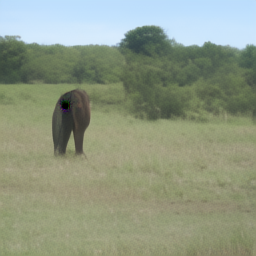

In [21]:
%cd /content/lightweight-diffusion-ldm

PROMPT = "an elephant standing in a field"
OUT = "outputs/ddim_20_fast"

!python inference.py \
  --prompt "$PROMPT" \
  --sampler ddim \
  --num-steps 20 \
  --eta 1.0 \
  --guidance-scale 3.0 \
  --precision fp32 \
  --batch-size 1 \
  --seed 123 \
  --low-vram \
  --decode-batch-size 1 \
  --output-dir "$OUT"

show_grid(OUT)

## 7. DDIM — standard 50-step run

`eta=0.0` makes DDIM deterministic for the same prompt and seed.


/content/lightweight-diffusion-ldm
Custom latent diffusion inference
Device: cuda
Precision: fp32
Sampler: ddim
Steps: 50
Guidance scale: 5.0
Eta: 0.0
Seed: 123
Total images: 1
Batch size: 1
Low VRAM: True
Decode batch size: 1
Output dir: outputs/ddim_50


Saved 1 images to outputs/ddim_50


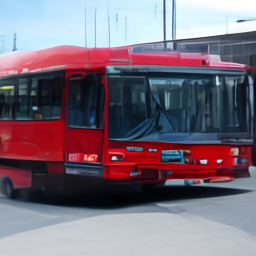

In [23]:
%cd /content/lightweight-diffusion-ldm

PROMPT = "a red bus parked beside a sidewalk "
OUT = "outputs/ddim_50"

!python inference.py \
  --prompt "$PROMPT" \
  --sampler ddim \
  --num-steps 50 \
  --eta 0.0 \
  --guidance-scale 5.0 \
  --precision fp32 \
  --batch-size 1 \
  --seed 123 \
  --low-vram \
  --decode-batch-size 1 \
  --output-dir "$OUT"

show_grid(OUT)

## 8. DDIM — stochastic variation with eta

Try `eta=0.3` or `eta=0.5` for more variation. `eta=0.0` is deterministic DDIM.


/content/lightweight-diffusion-ldm
Custom latent diffusion inference
Device: cuda
Precision: fp32
Sampler: ddim
Steps: 50
Guidance scale: 3.0
Eta: 0.5
Seed: 42
Total images: 1
Batch size: 1
Low VRAM: True
Decode batch size: 1
Output dir: outputs/ddim_eta_05


Saved 1 images to outputs/ddim_eta_05


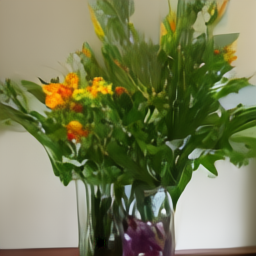

In [8]:
%cd /content/lightweight-diffusion-ldm

PROMPT = "a vase with flowers on a table"
OUT = "outputs/ddim_eta_05"

!python inference.py \
  --prompt "$PROMPT" \
  --sampler ddim \
  --num-steps 50 \
  --eta 0.5 \
  --guidance-scale 3.0 \
  --precision fp32 \
  --batch-size 1 \
  --seed 42 \
  --low-vram \
  --decode-batch-size 1 \
  --output-dir "$OUT"

show_grid(OUT)

## 9. DDPM

DDPM is much slower in this repo because `inference.py` uses the full diffusion schedule for DDPM. `--num-steps` is only used by DDIM.


/content/lightweight-diffusion-ldm
Custom latent diffusion inference
Device: cuda
Precision: fp32
Sampler: ddpm
Steps: 1000
Guidance scale: 3.0
Eta: 0.0
Seed: 42
Total images: 1
Batch size: 1
Low VRAM: True
Decode batch size: 1
Output dir: outputs/ddpm_1000


Saved 1 images to outputs/ddpm_1000


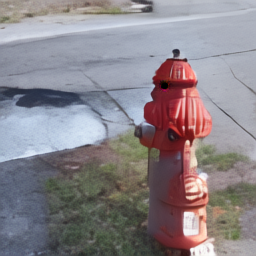

In [10]:
%cd /content/lightweight-diffusion-ldm

PROMPT = "a fire hydrant on a sidewalk"
OUT = "outputs/ddpm_1000"

!python inference.py \
  --prompt "$PROMPT" \
  --sampler ddpm \
  --guidance-scale 3.0 \
  --precision fp32 \
  --batch-size 1 \
  --seed 42 \
  --low-vram \
  --decode-batch-size 1 \
  --output-dir "$OUT"

show_grid(OUT)

## 10. DDIM — multiple images

Keep the batch small on Colab. This generates 4 images total using `batch-size 1`.


/content/lightweight-diffusion-ldm
Custom latent diffusion inference
Device: cuda
Precision: fp32
Sampler: ddim
Steps: 50
Guidance scale: 3.0
Eta: 0.0
Seed: 999
Total images: 4
Batch size: 1
Low VRAM: True
Decode batch size: 1
Output dir: outputs/ddim_four_images





Saved 4 images to outputs/ddim_four_images


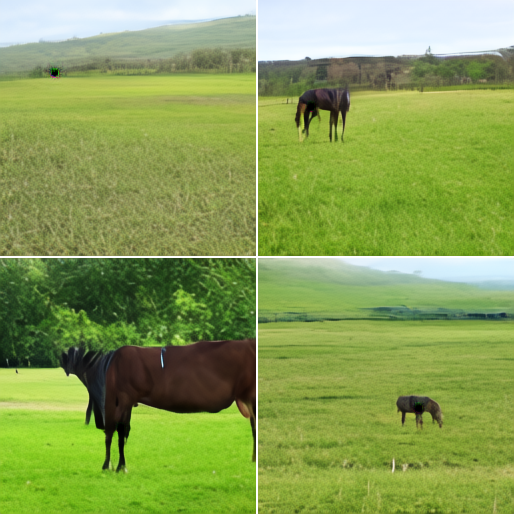

In [11]:
%cd /content/lightweight-diffusion-ldm

PROMPT = "a horse standing in a grassy field"
OUT = "outputs/ddim_four_images"

!python inference.py \
  --prompt "$PROMPT" \
  --sampler ddim \
  --num-steps 50 \
  --eta 0.0 \
  --guidance-scale 3.0 \
  --precision fp32 \
  --batch-size 1 \
  --num-images-per-prompt 4 \
  --seed 999 \
  --low-vram \
  --decode-batch-size 1 \
  --output-dir "$OUT"

show_grid(OUT)

## 11. DDIM — prompts file

Use one prompt per line.


/content/lightweight-diffusion-ldm
Custom latent diffusion inference
Device: cuda
Precision: fp32
Sampler: ddim
Steps: 50
Guidance scale: 3.0
Eta: 0.0
Seed: 42
Total images: 4
Batch size: 1
Low VRAM: True
Decode batch size: 1
Output dir: outputs/ddim_prompt_file





Saved 4 images to outputs/ddim_prompt_file


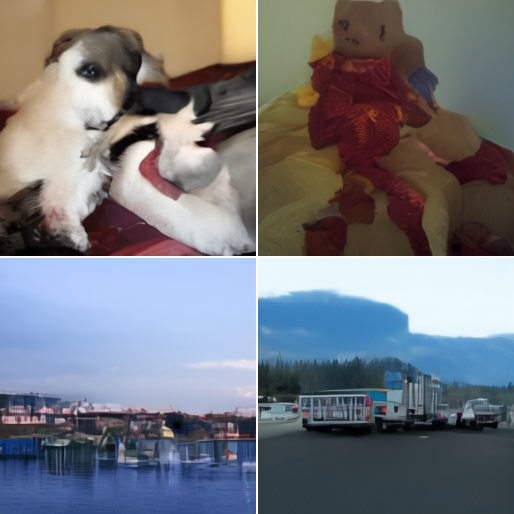

In [12]:
%cd /content/lightweight-diffusion-ldm

prompts = [
    "a dog sitting on a couch",
    "a teddy bear sitting on a bed",
    "a boat floating on a lake",
    "a truck driving on a highway",
]

with open("my_prompts.txt", "w") as f:
    f.write("\n".join(prompts))

OUT = "outputs/ddim_prompt_file"

!python inference.py \
  --prompts-file my_prompts.txt \
  --sampler ddim \
  --num-steps 50 \
  --eta 0.0 \
  --guidance-scale 3.0 \
  --precision fp32 \
  --batch-size 1 \
  --seed 42 \
  --low-vram \
  --decode-batch-size 1 \
  --output-dir "$OUT"

show_grid(OUT)